In [4]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

In [ ]:
# ── Load count tables ──────────────────────────────────────────────────────
ABE_OG_COUNTS   = pd.read_csv(BASE + 'counts/og/OG_ABE_COUNTS.txt',   sep='\t')
CBE_OG_COUNTS   = pd.read_csv(BASE + 'counts/og/OG_CBE_COUNTS.txt',   sep='\t')
ABE_EPO_COUNTS  = pd.read_csv(BASE + 'counts/focused/FC_ABE_EPO_COUNTS.txt',       sep='\t')
CBE_EPO_COUNTS  = pd.read_csv(BASE + 'counts/focused/FC_CBE_EPO_COUNTS_new.txt',   sep='\t')
ABE_BC_COUNTS   = pd.read_csv(BASE + 'counts/focused/FC_ABE_BC_COUNTS.txt',        sep='\t')
CBE_BC_COUNTS   = pd.read_csv(BASE + 'counts/focused/FC_CBE_BC_COUNTS_new.txt',    sep='\t')

# ── Sample lists used in LFC-FDR (exactly mirroring LFC_FDR_calculation.ipynb) ─
# Only sample columns (no sgRNA/gene/lib annotation columns)

ABE_OG_samps = [
    'bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5',
    'meninges1','meninges2','meninges3','meninges4','meninges5',
    'spleen1','spleen2','spleen3','spleen4',
    'input_rep1','input_rep2','input_rep3',
    'd5_rep1','d5_rep2','d5_rep3',
    'd15_rep1','d15_rep2','d15_rep3',
    'plasmidlib'
]

CBE_OG_samps = [
    'bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5',
    'bonemarrow6','bonemarrow7','bonemarrow8','bonemarrow9','bonemarrow10',
    'meninges1','meninges2','meninges3','meninges4','meninges5',
    'meninges6','meninges7','meninges8','meninges9','meninges10',
    'spleen1','spleen2','spleen3','spleen4','spleen5',
    'spleen6','spleen7','spleen8','spleen9',  # spleen10 excluded
    'input_rep1','input_rep2','input_rep3',
    'd5_rep1','d5_rep2','d5_rep3',
    'd15_rep1','d15_rep2','d15_rep3',
    'plasmidlib'
]

ABE_FC_samps = [
    'bm1','bm2','bm3','bm4','bm5',
    'spleen1','spleen2','spleen3','spleen4','spleen5',
    'd15-rep1','d15-rep2','d15-rep3','d15-rep4','d15-rep5',
    'd5','input','lib'
]

# ABE BC (null): bm2 and spleen2 excluded (abnormal skewing)
ABE_BC_samps = [s for s in ABE_FC_samps if s not in ('bm2', 'spleen2')]

CBE_EPO_samps = [
    'bm1','bm3','bm4','bm6','bm7','bm9','bm10',  # bm2,5,8 excluded
    'spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10',  # spleen2,5,8 excluded
    'd15-rep1','d15-rep3','d15-rep4','d15-rep5',  # d15-rep2 excluded (abnormal skewing)
    'd5','input','lib'
]

CBE_BC_samps = [
    'bm3','bm4','bm5','bm7','bm9',  # bm1,2,6,8,10 excluded (abnormal skewing)
    'spleen3','spleen4','spleen5','spleen7','spleen9',  # spleen1,2,6,8,10 excluded (abnormal skewing)
    'd15-rep1','d15-rep2','d15-rep3','d15-rep4','d15-rep5',
    'd5','input','lib'
]

# 2b

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[36.03498449 11.14300231]


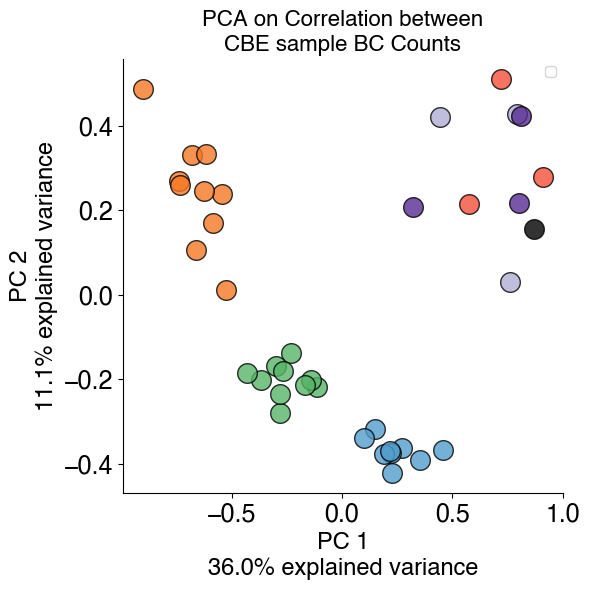

In [12]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
Xt = pca.fit_transform(CBE_OG_COUNTS[CBE_OG_COUNTS.columns[2:]].corr(method='spearman'))
fig, ax = plt.subplots(figsize=(6,6))

blues = sns.color_palette('Blues')
greens = sns.color_palette('Greens')
reds = sns.color_palette('Reds')
yellows = sns.color_palette('Oranges')
purples = sns.color_palette('Purples')

blues = blues.as_hex()
greens = greens.as_hex()
reds = reds.as_hex()
yellows = yellows.as_hex()

palette = (
    [blues[3]] * 9 +          # spleen1-9
    [greens[3]] * 10 +        # bonemarrow1-10
    [yellows[3]] * 10 +       # meninges1-10
    [reds[3]] * 3 +           # input_rep1-3
    [purples[2]] * 3 +        # d5_rep1-3
    [purples[5]] * 3 +        # d15_rep1-3
    ['black']                 # plasmidlib
)

for i in range(len(Xt)):
    ax.scatter(Xt[i][0], Xt[i][1], edgecolor='black', s=200, alpha=.8, c=palette[i])

ax.legend(loc='best')

var = pca.explained_variance_ratio_
print(var*100)
ax.set_xlabel(f'PC 1\n{np.round(var[0]*100, 1)}% explained variance', fontsize=17)
ax.set_ylabel(f'PC 2\n{np.round(var[1]*100, 1)}% explained variance', fontsize=17)
#ax.legend(bbox_to_anchor=(1.05, 1.))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=18,)
ax.set_title('PCA on Correlation between\nCBE sample BC Counts', fontsize=16)
fig.tight_layout()

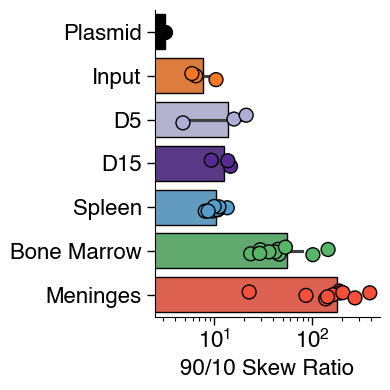

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


In [10]:
# ── 90/10 Skew Ratio — original figure2.ipynb style ───────────────────────
# barplot (mean per tissue group) + stripplot (individual samples), log x-scale
# Panels: OG ABE, OG CBE, Focused EPO ABE, Focused EPO CBE, Focused BC ABE, Focused BC CBE


palette_skew = ['black', yellows[3], purples[2], purples[5], blues[3], greens[3], reds[3]]
order_skew        = ['Plasmid', 'Input', 'D5', 'D15', 'Spleen', 'Bone Marrow']
order_skew_og     = ['Plasmid', 'Input', 'D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']

# tissue label maps
_tissue_label_og = {
    'plasmidlib': 'Plasmid',
    'input_rep': 'Input',
    'd5_rep': 'D5', 'd5': 'D5',
    'd15_rep': 'D15', 'd15-rep': 'D15',
    'spleen': 'Spleen',
    'bonemarrow': 'Bone Marrow',
    'meninges': 'Meninges',
    'bm': 'Bone Marrow',
    'input': 'Input',
    'lib': 'Plasmid',
    'men': 'Meninges',
}

def _tissue_label(samp):
    for prefix, label in _tissue_label_og.items():
        if samp.startswith(prefix):
            return label
    return samp

def _skew_df(counts_df, samp_cols):
    rows = []
    for s in samp_cols:
        d = sorted(counts_df[s].values)
        n = len(d)
        ten    = d[int(0.1 * n)]
        ninety = d[int(0.9 * n)]
        ratio  = ninety / ten if ten > 0 else np.nan
        rows.append({'Sample': s, 'Name': _tissue_label(s), '90/10 Skew Ratio': ratio})
    return pd.DataFrame(rows)

def plot_skew_single(counts_df, samp_cols, label, title, order=None):
    df = _skew_df(counts_df, samp_cols)

    fig, ax = plt.subplots(figsize=(4, 4))
    _order = order if order is not None else order_skew
    _palette = palette_skew[:len(_order)]
    sns.barplot(data=df, y='Name', x='90/10 Skew Ratio', ax=ax,
                edgecolor='black', linewidth=1,
                palette=_palette, order=_order)
    sns.stripplot(data=df, y='Name', x='90/10 Skew Ratio', ax=ax,
                  edgecolor='black', linewidth=1,
                  palette=_palette, order=_order, s=10)
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(mpl.ticker.LogLocator(base=10, numticks=10))
    ax.xaxis.set_major_formatter(mpl.ticker.LogFormatterMathtext())
    ax.set_ylabel('')
    ax.set_xlabel('90/10 Skew Ratio', fontsize=16)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=1, direction='out')
    ax.tick_params(axis='x', which='minor', length=3, width=0.8, direction='out')
    fig.tight_layout()
    plt.show()
    return fig

import os as _os
_os.makedirs(BASE + 'figure_final', exist_ok=True)

# OG screens
fig_cbe_og = plot_skew_single(CBE_OG_COUNTS, CBE_OG_samps, 'CBE', 'OG screens', order=order_skew_og)
fig_cbe_og.savefig(BASE + 'figure_final/skew_CBE_OG.pdf', bbox_inches='tight')

# fig_cbe_og = plot_skew_single(CBE_OG_COUNTS, CBE_OG_samps, 'CBE', 'OG screens', order=order_skew_og)
# fig_cbe_og.savefig(BASE + 'figure_final/skew_CBE_OG.pdf', bbox_inches='tight')

# # Focused EPO
# fig_abe_epo = plot_skew_single(ABE_EPO_COUNTS, ABE_BC_samps, 'ABE', 'Focused EPO screens')  # ABE EPO: same exclusions as ABE BC (bm2, spleen2)
# fig_abe_epo.savefig(BASE + 'figure_final/skew_ABE_EPO.pdf', bbox_inches='tight')

# fig_cbe_epo = plot_skew_single(CBE_EPO_COUNTS, CBE_EPO_samps, 'CBE', 'Focused EPO screens')
# fig_cbe_epo.savefig(BASE + 'figure_final/skew_CBE_EPO.pdf', bbox_inches='tight')

# # Focused BC / null
# fig_abe_bc = plot_skew_single(ABE_BC_COUNTS, ABE_BC_samps, 'ABE', 'Focused BC (null) screens')
# fig_abe_bc.savefig(BASE + 'figure_final/skew_ABE_BC.pdf', bbox_inches='tight')

# fig_cbe_bc = plot_skew_single(CBE_BC_COUNTS, CBE_BC_samps, 'CBE', 'Focused BC (null) screens')
# fig_cbe_bc.savefig(BASE + 'figure_final/skew_CBE_BC.pdf', bbox_inches='tight')